In [1]:
import sys
import os
from src.data.dataset_loader import WasteDatasetLoader
from src.data.preprocessing import DataPreprocessor
from src.models.model import WasteClassifier
import matplotlib.pyplot as plt

In [2]:
def test_model():
    """Test the model training pipeline"""
    # Load and preprocess data
    loader = WasteDatasetLoader()
    preprocessor = DataPreprocessor()
    
    # Get data - use only TrashNet instead of combined datasets
    images, labels = loader.load_trashnet()  
    processed_images, processed_labels = preprocessor.preprocess_images(images, labels)
    data_splits = preprocessor.create_train_val_test_split(processed_images, processed_labels)
    
    # Initialize and train model
    classifier = WasteClassifier()
    history = classifier.train(
        train_data=data_splits['train'],
        validation_data=data_splits['val'],
        epochs=5
    )
    
    return history

Loading TrashNet dataset...
Epoch 1/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 108s 660ms/step - accuracy: 0.2024 - loss: 1.9253 - val_accuracy: 0.2546 - val_loss: 1.9436
Epoch 2/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 70s 632ms/step - accuracy: 0.2232 - loss: 1.8024 - val_accuracy: 0.3325 - val_loss: 1.6577
Epoch 3/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 70s 630ms/step - accuracy: 0.3205 - loss: 1.6160 - val_accuracy: 0.4024 - val_loss: 1.5119
Epoch 4/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 71s 639ms/step - accuracy: 0.3814 - loss: 1.4990 - val_accuracy: 0.4182 - val_loss: 1.4503
Epoch 5/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 71s 636ms/step - accuracy: 0.4312 - loss: 1.3626 - val_accuracy: 0.4063 - val_loss: 1.4165


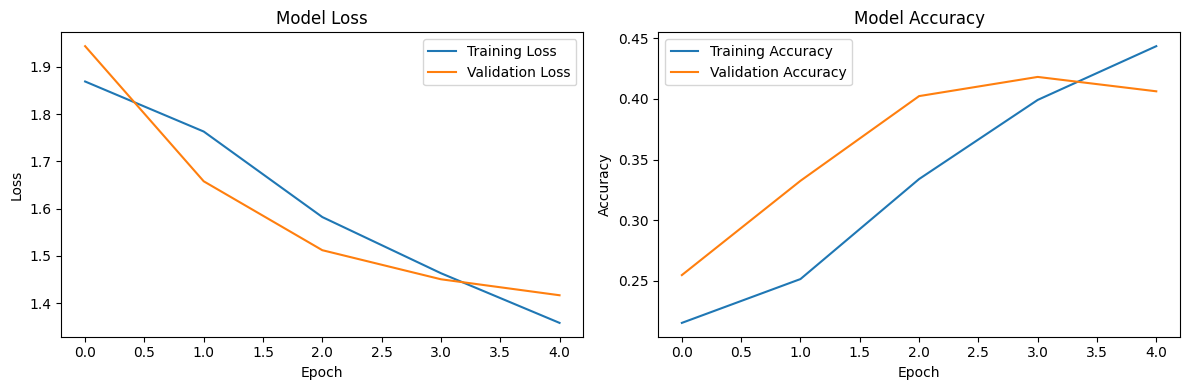

In [3]:
# Run the test
history = test_model()

# Plot training results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()